
# Multigrid for singular perturbed problems

In this example, we consider the equation

$$
- \frac{\partial^2 u}{\partial x^2} - \epsilon \frac{\partial^2 u}{\partial y^2} = f
$$


The scaling factor $\epsilon$ in diffusion ensures that the **approximation property** is destroyed. The following holds only:

$$ \|A_h^{-1} - p A_{H}^{-1} r \| \le C_A \frac{h^2}{\epsilon}
$$
For convergence to occur, a smoother must be used, whose **smoothing property** compensates for this accordingly. Thus, it should hold:
$$ \|A_h S_h^{\nu}\| \le C_s \frac{\epsilon }{h^2} \eta(\nu)
$$
A method with this property is referred to as a **robust smoother**.

## Initialization
First, we start as usual:


In [55]:

import sys
sys.path.append("..")
import modsimtools as util


In [56]:
import ug4py.pyugcore as ugcore
import ug4py.pyconvectiondiffusion as cd

In [57]:
import json

In [58]:
myconfig = { 
    "geometry": {
        "numRefs": 7,
        "gridName": "grids/laplace_sample_grid_2d-tri.ugx",
        "requiredSubsets": ["Inner", "Boundary"]
    },
        
    "order":  None,
    
    "problem": {
        "id": "PoissonProblem",
        "parameters": {"cmp": "u", "epsx": 1.0, "epsy": 0.01}
        #"id": "ConvectionDiffusionProblem",
        #"parameters": {"cmp": "u", "eps": 1.0, "velx": 0.01, "vely": 0.01, "upwind" : True}
    }
}

jconfig = json.loads(json.dumps(myconfig))


In [59]:
jgeometry= jconfig["geometry"]

jgeometry["gridName"]
jconfig["problem"]

{'id': 'PoissonProblem', 'parameters': {'cmp': 'u', 'epsx': 1.0, 'epsy': 0.01}}

In [60]:

dom =  util.CreateDomain(jgeometry["gridName"], jgeometry["numRefs"], jgeometry["requiredSubsets"])
approxSpace = util.CreateApproximationSpace(dom, dict(fct = "u", type = "Lagrange", order = 1))

Loading Domain 'grids/laplace_sample_grid_2d-tri.ugx'...
Domain loaded.
Refining ...
Refining step {0} ...
Refining step {1} ...
Refining step {2} ...
Refining step {3} ...
Refining step {4} ...
Refining step {5} ...
Refining step {6} ...
Refining done
Approximation space:
| ---------------------------------------------------------------------------- |
|  Number of DoFs (All Procs)                                                  |
|  Algebra: Block 1 (divide by 1 for #Index)                                   |
|                                                                              |
|    GridLevel   |       Domain |     0: Inner |  1: Boundary                  |
| ---------------------------------------------------------------------------- |
| (lev,    0)    |            9 |            1 |            8 |
| (lev,    1)    |           25 |            9 |           16 |
| (lev,    2)    |           81 |           49 |           32 |
| (lev,    3)    |          289 |          225 |

## Ordering of the unknowns
The following command reorders the unknowns:

In [61]:
ugcore.OrderLex(approxSpace, "x")    # order vertices (and dofs) lexicographically

OrderLex: LexOrdering in +x direction.


In [62]:
# import problem from configs

from config.PoissonProblem import PoissonProblem as Problem 
#from config.ConvectionDiffusionProblem import ConvectionDiffusionProblem as Problem 
problem_desc = jconfig["problem"]

# problem=getattr(Problem, problem_desc["id"])
problem = Problem(**problem_desc["parameters"])
#problem = Problem(**problem_desc["parameters"])

domainDisc = ugcore.DomainDiscretization2dCPU1(approxSpace)
problem.add_element_discretizations(domainDisc)
problem.add_boundary_conditions(domainDisc)


epsx=1.0
epsy=0.01


In [63]:
ugcore.GaussSeidelCPU1

ug4py.pyugcore.GaussSeidelCPU1

## Gauß-Seidel method

The Gauß-Seidel method converges. For $\epsilon \rightarrow 0$ it does not provide a **robust smoother** however:

In [64]:
#solve problem with max 50 iterations, 
#reducing the error by 6 orders of magnitude  
convCheck = ugcore.ConvCheckCPU1()
convCheck.set_maximum_steps(50)
convCheck.set_reduction(1e-6)
convCheck.set_minimum_defect(1e-15)
convCheck.set_supress_unsuccessful(True)


solver = ugcore.LinearSolverCPU1()
solver.set_convergence_check(convCheck)

# dbgWriter = ugcore.GridFunctionDebugWriter2dCPU1(approxSpace)
# solver:set_debug(dbgWriter)

In [65]:
import toolbox as tools

In [66]:
gs = ugcore.GaussSeidelCPU1()
solver.set_preconditioner(gs)

tools.SolverTest(domainDisc, approxSpace, solver, convCheck, "Error_GS.vtk");


   % %%%%%%%%  Iterative Linear Solver   %%%%%%%%%%%%%%%%%%
   % %%%%%%%%   (Precond: Gauss-Seidel)  %%%%%%%%%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    3.641221e+02      -------
Results: 50 steps (rho=0.8620052654183156)
Time: 0.050956 seconds
   %    1:    1.347304e+02    3.700143e-01
   %    2:    5.274690e+01    3.914996e-01
   %    3:    2.290760e+01    4.342929e-01
   %    4:    1.167082e+01    5.094736e-01
   %    5:    7.091444e+00    6.076218e-01
   %    6:    4.943560e+00    6.971161e-01
   %    7:    3.760529e+00    7.606926e-01
   %    8:    3.020298e+00    8.031576e-01
   %    9:    2.514725e+00    8.326082e-01
   %   10:    2.147951e+00    8.541494e-01
   %   11:    1.869907e+00    8.705541e-01
   %   12:    1.651969e+00    8.834495e-01
   %   13:    1.476594e+00    8.938389e-01
   %   14:    1.332446e+00    9.023783e-01
   %   15:    1.211878e+00    9.095136e-01
   %   16:    1.109545e+00    9.155583e-01
   %   17:    1.021602e+00    9.207398e-01
   %

## ILU method
The ILU scheme is robust. For the limit case $\epsilon \rightarrow 0$ an exact solver is obtained:

In [67]:
ilu = ugcore.ILUCPU1()
solver.set_preconditioner(ilu)
tools.SolverTest(domainDisc, approxSpace, solver, convCheck,"Error_ILU.vtk");


   % %%%%%%%%  Iterative Linear Solver  %%%%%%%%%%%%%%%%%%%
   % %%%%%%%%   (Precond: ILU)          %%%%%%%%%%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    3.641221e+02      -------
Results: 50 steps (rho=0.758685840685412)
Time: 0.089604 seconds
   %    1:    1.804536e+00    4.955855e-03
   %    2:    2.554226e-01    1.415447e-01
   %    3:    1.454850e-01    5.695857e-01
   %    4:    9.353526e-02    6.429201e-01
   %    5:    6.306446e-02    6.742319e-01
   %    6:    4.371482e-02    6.931768e-01
   %    7:    3.088458e-02    7.065014e-01
   %    8:    2.214383e-02    7.169866e-01
   %    9:    1.608112e-02    7.262123e-01
   %   10:    1.182462e-02    7.353108e-01
   %   11:    8.812090e-03    7.452322e-01
   %   12:    6.669397e-03    7.568462e-01
   %   13:    5.141243e-03    7.708708e-01
   %   14:    4.049841e-03    7.877163e-01
   %   15:    3.269024e-03    8.071982e-01
   %   16:    2.708113e-03    8.284164e-01
   %   17:    2.301500e-03    8.498536e-01
   % 

## Mehrgitterverfahren


In [68]:
mgConfig = {
    "type" : "linear",  # linear solver type ["bicgstab", "cg", "linear"]
    "precond" : 
    {
        "type"        : "gmg",    # preconditioner ["gmg", "ilu", "ilut", "jac", "gs", "sgs"]
        
        "smoother"    : "gs",     # gmg-smoother ["ilu", "ilut", "jac", "gs", "sgs"]
        "cycle"       : "V",      # gmg-cycle ["V", "F", "W"]
        "preSmooth"   : 1,        # number presmoothing steps
        "postSmooth"  : 1,        # number postsmoothing steps
        "rap"         : False,    # computes RAP-product instead of assembling if true 
        
        "baseLevel"   : 0,        # gmg - baselevel
        "baseSolver"  : "lu",
    },

    "convCheck" : "standard"
}


In [69]:
def CreateMultiGridSolver(approxSpace, domainDisc, mysmoother) :
    mg = ugcore.GeometricMultiGrid2dCPU1(approxSpace)  # Konstruktor
    mg.set_discretization(domainDisc)
    mg.set_base_level(0)          # Multi-grid

    # Configuration of the smoother.
    mg.set_smoother(mysmoother)                  
    mg.set_num_presmooth(1)   # Vorglaettung
    mg.set_num_postsmooth(1)  #  Nachglaettung
    mg.set_rap(False)          # fuer Galerkinprodukt A_H=RAP, if true (alternative: assemble coarse system)

    # Konfiguration Grobgitterloeser
    baseSolver = ugcore.LUCPU1()
    mg.set_base_level(0)          # Multi-grid
    mg.set_base_solver(baseSolver)     

    mg.set_cycle_type("V")       # Select cycle type "V,W,F".
    return mg


In [70]:
mg = CreateMultiGridSolver(approxSpace, domainDisc,gs)
solver.set_preconditioner(mg)
tools.SolverTest(domainDisc, approxSpace, solver, convCheck,"Error_GMG.vtk");


   % %%%%%%%%      Iterative Linear Solver      %%%%%%%%%%%
   % %%%%%%%%   (Precond: Geometric MultiGrid)  %%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    3.641221e+02      -------
Results: 50 steps (rho=0.8280859389032281)
Time: 0.210596 seconds
   %    1:    4.738596e+01    1.301376e-01
   %    2:    9.562835e+00    2.018074e-01
   %    3:    3.794558e+00    3.968027e-01
   %    4:    2.260918e+00    5.958318e-01
   %    5:    1.591165e+00    7.037691e-01
   %    6:    1.216584e+00    7.645872e-01
   %    7:    9.770330e-01    8.030954e-01
   %    8:    8.104528e-01    8.295039e-01
   %    9:    6.877803e-01    8.486371e-01
   %   10:    5.935913e-01    8.630536e-01
   %   11:    5.189406e-01    8.742390e-01
   %   12:    4.582869e-01    8.831200e-01
   %   13:    4.080176e-01    8.903105e-01
   %   14:    3.656793e-01    8.962341e-01
   %   15:    3.295472e-01    9.011918e-01
   %   16:    2.983725e-01    9.054014e-01
   %   17:    2.712275e-01    9.090231e-01
   %

Wir testen, indem wir eine Nullfolge $\epsilon_k$ betrachten.

In [71]:

def robustness_test(solver, conv_check, epsy_start=1.0, epsy_stop=1e-6, epsy_factor=3.16227766016):

    eps=[]
    rates =[]
    # Print solver config.
    print(solver.config_string())
    
    # Set initial values for the loop
    epsy = epsy_start
    
    while epsy >= epsy_stop:
        # Update the configuration parameter
        myconfig["problem"]["parameters"]['epsy'] = epsy
        print(f"1/eps={1.0 / myconfig["problem"]["parameters"]['epsy']}")

        # Initialize variables to store results
        my_residuals = None
        my_rate = None
        my_steps = None

        # Create domain discretization and run the solver test
        print(myconfig["problem"]["parameters"])
        problem = Problem(**myconfig["problem"]["parameters"])

        domainDisc = ugcore.DomainDiscretization2dCPU1(approxSpace)
        problem.add_element_discretizations(domainDisc)
        problem.add_boundary_conditions(domainDisc)
       
        my_residuals = tools.SolverTest(domainDisc, approxSpace, solver, convCheck, "ErrorMGV")
        my_rate=convCheck.avg_rate()
        my_steps=convCheck.step()
        
        # Store the results
        eps.append(1.0 / myconfig["problem"]["parameters"]['epsy'])
        rates.append(my_rate)
        print("=========")

        # Update epsy for the next iteration
        epsy /= epsy_factor

        print(eps)
        print(rates)
    return eps, rates

In [72]:
eps = []
rates_ilu=[]

mg = CreateMultiGridSolver(approxSpace, domainDisc,ilu)
solver.set_preconditioner(mg)
eps, rates_ilu = robustness_test(solver, convCheck, 1.0, 1e-5, 3.16227766016)

Iterative Linear Solver
 Convergence Check: StdConvCheck( max steps = 50, min defect = 1e-15, relative reduction = 1e-06)
 Preconditioner: 
 | GeometricMultigrid (V-Cycle)
 |  Smoother (1x pre, 1x post): ILU( damping = ConstantDamping(1))
 |  Basesolver ( Baselevel = 0, gathered base = true): 
 |  # LU Decomposition: Direct Solver for Linear Equation Systems.
 |  #  Minimum Entries for Sparse LU: 4000

1/eps=1.0
{'cmp': 'u', 'epsx': 1.0, 'epsy': 1.0}
epsx=1.0
epsy=1.0
Results: 5 steps (rho=0.050842893334695105)
Time: 0.065151 seconds

   % %%%%%%%%      Iterative Linear Solver      %%%%%%%%%%%
   % %%%%%%%%   (Precond: Geometric MultiGrid)  %%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    6.574081e+02      -------
5
ErrorMGV
[1.0]
[0.050842893334695105]
1/eps=3.16227766016
{'cmp': 'u', 'epsx': 1.0, 'epsy': 0.3162277660176759}
epsx=1.0
epsy=0.3162277660176759
   %    1:    7.543480e+00    1.147458e-02
   %    2:    3.268962e-01    4.333493e-02
   %    3:    2.455368e-02  

In [73]:
eps = []
rates_gs=[]
mg = CreateMultiGridSolver(approxSpace, domainDisc,gs)
solver.set_preconditioner(mg)
eps, rates_gs = robustness_test(solver, convCheck, 1.0, 1e-5, 3.16227766016)

Iterative Linear Solver
 Convergence Check: StdConvCheck( max steps = 50, min defect = 1e-15, relative reduction = 1e-06)
 Preconditioner: 
 | GeometricMultigrid (V-Cycle)
 |  Smoother (1x pre, 1x post): Gauss-Seidel( damping = ConstantDamping(1))
 |  Basesolver ( Baselevel = 0, gathered base = true): 
 |  # LU Decomposition: Direct Solver for Linear Equation Systems.
 |  #  Minimum Entries for Sparse LU: 4000

1/eps=1.0
{'cmp': 'u', 'epsx': 1.0, 'epsy': 1.0}
epsx=1.0
epsy=1.0

   % %%%%%%%%Results: 9 steps (rho=0.1933383341383385)
Time: 0.061772 seconds
      Iterative Linear Solver      %%%%%%%%%%%
   % %%%%%%%%   (Precond: Geometric MultiGrid)  %%%%%%%%%%%
   %   Iter      Defect         Rate 
   %    0:    6.574081e+02      -------
   %    1:    6.320473e+01    9.614230e-02
   %    2:    9.076614e+00    1.436066e-01
   %    3:    1.596155e+00    1.758536e-01
   %    4:    3.278717e-01    2.054134e-01
   %    5:    7.374150e-02    2.249096e-01
   %    6:    1.724531e-02    2.338616e

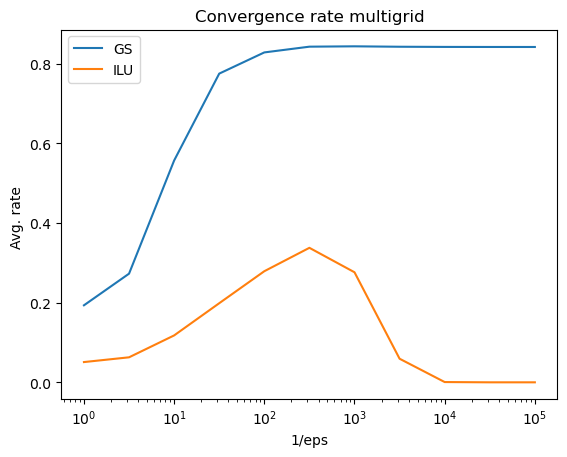

In [74]:

import matplotlib.pyplot as plt
plt.plot(eps, rates_gs, label="GS")
plt.plot(eps, rates_ilu, label="ILU")

plt.title("Convergence rate multigrid")
plt.xscale("log")
plt.xlabel("1/eps")

plt.ylabel("Avg. rate ")
plt.legend()